In [ ]:
!pip install mlflow

In [ ]:
import mlflow

mlflow.set_experiment("Train Combined Models - Literacy")
with mlflow.start_run(run_name="Train Combined Models - Literacy"):
    # Seu código para treinar modelos combinados de alfabetização
    mlflow.log_param("model_type", "combined")
    mlflow.log_artifact("../models/literacy_combined", artifact_path="combined_literacy_model_checkpoints")
    mlflow.log_param("input", "Combined training and validation data folds: ../data/processed/folds/")
    mlflow.log_param("output", "Model checkpoints and training logs: ../models/literacy_combined/")
    mlflow.set_tag("aws_instance_type", "2vCPU + 8 GiB")

## Pre-requisites

Before running this notebook, you should have already used the `extract_features.py` script to extract features from models trained on DHS data. You should have the following structure under the `outputs/` directory:

```
dhs_ooc/
    DHS_OOC_A_ms_samescaled_b64_fc01_conv01_lr0001/
        features.npz
    ...
    DHS_OOC_E_rgb_same_b64_fc001_conv001_lr0001/
        features.npz
dhs_incountry/
    DHS_Incountry_A_ms_samescaled_b64_fc01_conv01_lr001/
        features.npz
    ...
    DHS_Incountry_E_nl_random_b64_fc01_conv01_lr001/
        features.npz
transfer/
    transfer_nlcenter_ms_b64_fc001_conv001_lr0001/
        features.npz
    transfer_nlcenter_rgb_b64_fc001_conv001_lr0001/
        features.npz
        

TODO: update when keep-frac models are added
```

## Instructions

This notebook essentially performs fine-tuning of the final-layer of the Resnet-18 models. However, instead of directly fine-tuning the Resnet-18 models in TensorFlow, we train ridge-regression models using the extracted features. We take this approach for two reasons:

1. It is easier to perform leave-one-group-out ("logo") cross-validated ridge regression using scikit-learn, as opposed to TensorFlow. For out-of-country (OOC) experiments, the left-out group is the test country. For in-country experiments, the left-out group is the test split.
2. We can concatenate the 512-dim features from the RGB/MS CNN models with the 512-dim features from the NL CNN models to form a larger 1024-dim feature vector capturing RGB/MS + NL imagery information. We do this instead of training a CNN with the MS+NL imagery stacked together as an input because we found it to result in better performance.

Because of the extensive cross-validation, each "logo" CV run may take ~2-4 hours. In total, this notebook may take upwards of 15 hours to complete.

After you complete this notebook, use the `model_analysis/dhs_ooc.ipynb` and `model_analysis/dhs_incountry.ipynb` (TODO) notebooks to analyze the final performance of the fine-tuned Resnet-18 models.

## Imports and Constants

In [1]:
%cd '/hdd/home/abenabbes/Ali-a/'
%load_ext autoreload
%autoreload 2
%matplotlib inline
!pwd

/home/abenabbes/Ali-a
/home/abenabbes/Ali-a


In [2]:
!pip install matplotlib

You should consider upgrading via the '/usr/local/bin/python3.7 -m pip install --upgrade pip' command.


In [14]:
from __future__ import annotations

from collections.abc import Iterable
import os
import pickle

import numpy as np
import pandas as pd

import sklearn.linear_model

from batchers import dataset_constants
from models.linear_model import ridge_cv, train_linear_model
from utils.general import load_npz

In [4]:
FOLDS = ['A', 'B', 'C', 'D', 'E']
SPLITS = ['train', 'val', 'test']
label = 'literacy'
OUTPUTS_ROOT_DIR = f'/root/logs/{label}'
INPUTS_ROOT_DIR = f'/root/final_ex/{label}'
COUNTRIES = dataset_constants.DHS_COUNTRIES

KEEPS = [0.05, 0.1, 0.25, 0.5]
SEEDS = [123, 456, 789]

## Load data

In [5]:
MODEL_DIRS = {
    #Incountry models - NightLight
    
    #'incountry_resnet_nl_A':'DHS_Incountry_A_nl_random_b64_fc1.0_conv1.0_lr0001',
    #'incountry_resnet_nl_B':'DHS_Incountry_B_nl_random_b64_fc1.0_conv1.0_lr0001',
    #'incountry_resnet_nl_C':'DHS_Incountry_C_nl_random_b64_fc1.0_conv1.0_lr0001',
    #'incountry_resnet_nl_D':'DHS_Incountry_D_nl_random_b64_fc1.0_conv1.0_lr0001',
    #'incountry_resnet_nl_E':'DHS_Incountry_E_nl_random_b64_fc1_conv1.0_lr001',
    
    #Incountry models - MultiSpectral
    
    'incountry_resnet_ms_A':'DHS_Incountry_A_ms_samescaled_b64_fc01_conv01_lr001',
    'incountry_resnet_ms_B':'DHS_Incountry_B_ms_samescaled_b64_fc1_conv1_lr001',
    'incountry_resnet_ms_C':'DHS_Incountry_C_ms_samescaled_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_ms_D':'DHS_Incountry_D_ms_samescaled_b64_fc001_conv1.0_lr0001',
    'incountry_resnet_ms_E':'DHS_Incountry_E_ms_samescaled_b64_fc001_conv001_lr0001',
    
}

`country_labels` is a `np.ndarray` that shows which country each cluster belongs to. Countries are indexed by their position in `dataset_constants.DHS_COUNTRIES`.
```python
array([ 0,  0,  0, ..., 22, 22, 22])
```

`incountry_group_labels` is a `np.ndarray` that shows which "test" fold each cluster belongs to. The first cluster belongs to the "test" split of fold "B" (folds here are 0-indexed).
```python
array([1, 1, 4, ..., 1, 0, 3])
```

In [6]:
countries=["brazil"]

print(len(countries))

1


In [7]:
FOLDS = ["A", "B", "C", "D", "E"]
indicators = ['income','longevity','literacy']
for label in indicators:
    df = pd.read_csv('/root/Datasets/SelectedClusters/dataset_clean.csv', float_precision='high', index_col=False)
    labels = df[label].to_numpy(dtype=np.float32)
    print(labels)

[0.60837847 0.32027468 0.60319483 ... 0.40979037 0.5846954  0.278993  ]
[0.6        0.71666664 0.6666667  ... 0.78333336 0.7203095  0.7770141 ]
[0.81876063 0.9183987  0.912963   ... 1.         0.97577375 0.73439777]


In [8]:
indicators = ['income','longevity','literacy']
for label in indicators:
    print(f'for label {label}')
    df = pd.read_csv('/root/Datasets/SelectedClusters/dataset_clean.csv', float_precision='high', index_col=False)
    labels = df[label].to_numpy(dtype=np.float32)
    print(labels)
    print(len(labels))
    locs = df[['lat', 'lon']].to_numpy(dtype=np.float32)
    country_labels = df['country'].map(countries.index).to_numpy()
    print(country_labels)

with open('/root/Datasets/SelectedClusters/dhs_incountry_co.pkl', 'rb') as f:
    incountry_folds = pickle.load(f)
incountry_group_labels = np.zeros(len(df), dtype=np.int64)
for i, fold in enumerate(FOLDS):
    test_indices = incountry_folds[fold]['test']
    print(test_indices)
    incountry_group_labels[test_indices] = i
    print(i)


for label income
[0.60837847 0.32027468 0.60319483 ... 0.40979037 0.5846954  0.278993  ]
30000
[0 0 0 ... 0 0 0]
for label longevity
[0.6        0.71666664 0.6666667  ... 0.78333336 0.7203095  0.7770141 ]
30000
[0 0 0 ... 0 0 0]
for label literacy
[0.81876063 0.9183987  0.912963   ... 1.         0.97577375 0.73439777]
30000
[0 0 0 ... 0 0 0]
[    1     4     8 ... 29981 29982 29995]
0
[    7     9    12 ... 29989 29990 29993]
1
[    0     5     6 ... 29997 29998 29999]
2
[    2    14    17 ... 29986 29991 29996]
3
[    3    11    20 ... 29988 29992 29994]
4


In [9]:
label = 'literacy'

print(f'for label {label}')
df = pd.read_csv('/root/Datasets/SelectedClusters/dataset_clean.csv', float_precision='high', index_col=False)
npz = load_npz(f'/root/Datasets/SelectedClusters/dhs_co_{label}.npz')
labels = npz['labels']
print(labels)
print(len(labels))
locs = npz['locs']
country_labels = df['country'].map(countries.index).to_numpy()
print(country_labels)

with open('/root/Datasets/SelectedClusters/dhs_incountry_co.pkl', 'rb') as f:
    incountry_folds = pickle.load(f)
incountry_group_labels = np.zeros(len(df), dtype=np.int64)
for i, fold in enumerate(FOLDS):
    test_indices = incountry_folds[fold]['test']
    print(test_indices)
    incountry_group_labels[test_indices] = i
    print(i)

for label literacy
image_hists: dtype=int64, shape=(30000, 8, 102)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)
nls_center: dtype=float32, shape=(30000,)
nls_mean: dtype=float32, shape=(30000,)
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
30000
[0 0 0 ... 0 0 0]
[    1     4     8 ... 29981 29982 29995]
0
[    7     9    12 ... 29989 29990 29993]
1
[    0     5     6 ... 29997 29998 29999]
2
[    2    14    17 ... 29986 29991 29996]
3
[    3    11    20 ... 29988 29992 29994]
4


## Incountry

### Ridge Regression using only the best set

In [15]:
f = 'E'
num_examples = len(labels)
model_name = 'incountry_resnet_ms'
model_fold_name = f'{model_name}_{f}'
print(model_fold_name)
model_dir = MODEL_DIRS[model_fold_name]
npz_path = os.path.join(INPUTS_ROOT_DIR, 'dhsincountry', model_dir, 'features.npz')
print(labels)
npz = load_npz(npz_path, check={'labels': labels})
features = npz['features']
X = features[np.arange(num_examples)]
y = labels[np.arange(num_examples)]
X_train = features[incountry_folds[f]['train']]
y_train = labels[incountry_folds[f]['train']]
X_val = features[incountry_folds[f]['val']]
y_val = labels[incountry_folds[f]['val']]
X_test = features[incountry_folds[f]['test']]
y_test = labels[incountry_folds[f]['test']]

best_model, best_train_preds, best_val_preds = train_linear_model(X_train, y_train, X_val, y_val,
                       linear_model=sklearn.linear_model.Ridge,
                       plot_alphas=False, optimize='r2')

test_preds = best_model.predict(X)

savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_ms/only_e')
filename = 'test_preds.npz'
npz_path = os.path.join(savedir, filename)
save_dict = {}
if savedir is not None:
        os.makedirs(savedir, exist_ok=True)

        # build up save_dict
        if 'labels' in save_dict:
            assert np.array_equal(labels, save_dict['labels'])
        save_dict['labels'] = labels
        save_dict['test_preds'] = test_preds

        print('saving test preds to:', npz_path)
        np.savez_compressed(npz_path, **save_dict)

incountry_resnet_ms_E
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
features: dtype=float32, shape=(30000, 512)
preds: dtype=float32, shape=(30000,)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)


/usr/local/lib/python3.7/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/usr/local/lib/python3.7/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/usr/local/lib/python3.7/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/usr/local/lib/python3.7/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/usr/local/lib/python3.7/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation 

saving test preds to: /root/logs/literacy/resnet_ms/only_e/test_preds.npz


### Ridge Regression with k-Fold Cross Validation for ResNet-NL and ResNet-MS models

In [16]:
def ridgecv_incountry_wrapper(model_name: str, savedir: str) -> None:
    '''
    Args
    - model_name: str, corresponds to keys in MODEL_DIRS (without the fold suffix)
    - savedir: str, path to directory for saving ridge regression weights and predictions
    '''
    features_dict = {}
    for f in FOLDS:
        model_fold_name = f'{model_name}_{f}'
        print(model_fold_name)
        model_dir = MODEL_DIRS[model_fold_name]
        npz_path = os.path.join(INPUTS_ROOT_DIR, 'dhsincountry', model_dir, 'features.npz')
        print(labels)
        npz = load_npz(npz_path, check={'labels': labels})
        features_dict[f] = npz['features']

    ridge_cv(
        features=features_dict,
        labels=labels,
        group_labels=incountry_group_labels,
        group_names=FOLDS,
        do_plot=True,
        savedir=savedir,
        save_weights=True,
        verbose=True)

incountry_resnet_ms_A
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
features: dtype=float32, shape=(30000, 512)
preds: dtype=float32, shape=(30000,)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)
incountry_resnet_ms_B
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
features: dtype=float32, shape=(30000, 512)
preds: dtype=float32, shape=(30000,)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)
incountry_resnet_ms_C
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
features: dtype=float32, shape=(30000, 512)
preds: dtype=float32, shape=(30000,)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)
incountry_resnet_ms_D
[0.84686154 0.9242118  0.91085756 ... 0.8564527  0.8138704  0.9399967 ]
features: dtype=float32, shape=(30000, 512)
pred

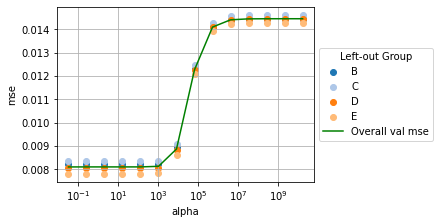

best val mse: 0.008, best alpha: 0.03125, test mse: 0.008
Group: B
Alpha: 17179869184.0 (14/14)
best val mse: 0.009, best alpha: 0.03125, test mse: 0.009
Group: C
Alpha: 17179869184.0 (14/14)
best val mse: 0.009, best alpha: 0.03125, test mse: 0.009
Group: D
Alpha: 17179869184.0 (14/14)
best val mse: 0.008, best alpha: 0.03125, test mse: 0.008
Group: E
Alpha: 17179869184.0 (14/14)
best val mse: 0.007, best alpha: 0.03125, test mse: 0.007
saving test preds to: /root/logs/literacy/resnet_ms/test_preds.npz
saving ridge_weights to: /root/logs/literacy/resnet_ms/ridge_weights.npz


In [17]:
model_name = 'incountry_resnet_ms'
savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_ms')
ridgecv_incountry_wrapper(model_name, savedir)